In [ ]:
# bibliotecas que necesitaremos 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Carga y vistazo inicial del df

In [ ]:

# pip install -r requirements.txt
# pip install openpyxl

# cargo los datos desde el archivo de Excel (.xlsx)
# El archivo tiene 4 hojas, solo 2 son relevantes para el análisis, el resto son metadatos

# cargaré las hojas "tipos de cambio" y "llegadas de turistas"

# Cargar tipos de cambio (datos diarios)
tc_df = pd.read_excel('tc_turistas.xlsx', sheet_name='tipos de cambio')

# Cargar turistas (datos mensuales) 
turistas_df = pd.read_excel('tc_turistas.xlsx', sheet_name='llegadas de turistas')

# En este caso, no hizo falta hacer "skiprows", ya que los metadatos estaban en hoja aparte

print("Datos cargados exitosamente")
print(f"Tipos de cambio: {tc_df.shape}")
print(f"Turistas: {turistas_df.shape}")

# .shape devuelve una tupla (filas, columnas) del dataframe


Datos cargados exitosamente
Tipos de cambio: (1004, 3)
Turistas: (99, 8)


In [ ]:
# muestro las primeras 5 filas de cada dataset

tc_df.head()

# vemos valores sospechosos, varios NaN, faltaría verificar tipo de dato

,FECHA,DOLAR Oficial,DOLAR Blue
0,2017-06-01,16.25,16.30
1,2017-06-02,16.20,16.32
2,2017-06-03,NaN,NaN
3,2017-06-04,NaN,NaN
4,2017-06-05,16.20,16.34


In [8]:
turistas_df.head()

,anio,mes,date,Bolivia,Brasil,Chile,Paraguay,Uruguay
0,2013,ene,41275,141417.459190,112996.623524,66007.699999,50277.720853,52456.413939
1,2013,feb,41306,95204.256341,161366.098439,62013.313451,52666.951095,41377.875955
2,2013,mar,41334,82862.061107,96727.365114,81096.057038,92714.958474,43728.713276
3,2013,abr,41365,72009.462620,66978.888460,55096.585327,67716.242304,27458.646062
4,2013,may,41395,79131.435938,63886.966089,61641.446807,70544.694702,23592.398421


In [28]:
# vemos la información de los df
print("*"*60)
print("Dataframe Tipos de Cambio")
print("*"*60)
tc_df.info()

print("\n")
print("Nombres de columnas: ", tc_df.columns.tolist())

print("\n")
print("Cantidad de valores nulos por columna:")
print(f"Dólar Oficial: {tc_df['dolar_oficial'].isnull().sum()}")
print(f"Dólar Blue: {tc_df['dolar_blue'].isnull().sum()}")

************************************************************
Dataframe Tipos de Cambio
************************************************************
<class 'pandas.DataFrame'>
RangeIndex: 1004 entries, 0 to 1003
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   fecha          1004 non-null   datetime64[us]
 1   dolar_oficial  668 non-null    float64       
 2   dolar_blue     671 non-null    float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 23.7 KB


Nombres de columnas:  ['fecha', 'dolar_oficial', 'dolar_blue']


Cantidad de valores nulos por columna:
Dólar Oficial: 336
Dólar Blue: 333


In [25]:
print("*"*60)
print("Dataframe Llegadas de Turistas")
print("*"*60)
turistas_df.info()

print("\n")
print("Nombres de columnas: ", turistas_df.columns.tolist())
print("\n")

************************************************************
Dataframe Llegadas de Turistas
************************************************************
<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype        
---  ------    --------------  -----        
 0   anio      99 non-null     int64        
 1   mes       99 non-null     str          
 2   date      99 non-null     datetime64[s]
 3   bolivia   99 non-null     float64      
 4   brasil    99 non-null     float64      
 5   chile     99 non-null     float64      
 6   paraguay  99 non-null     float64      
 7   uruguay   99 non-null     float64      
dtypes: datetime64[s](1), float64(5), int64(1), str(1)
memory usage: 6.6 KB


Nombres de columnas:  ['anio', 'mes', 'date', 'bolivia', 'brasil', 'chile', 'paraguay', 'uruguay']




In [22]:
# normalizo los nombres de las columnas
tc_df.columns = tc_df.columns.str.strip().str.lower().str.replace(' ', '_')
turistas_df.columns = turistas_df.columns.str.strip().str.lower().str.replace(' ', '_')

print("Columnas:")
print("Dataframe tipos de cambio:", tc_df.columns.to_list())
print("Dataframe turistas:", turistas_df.columns.to_list())

Columnas:
Dataframe tipos de cambio: ['fecha', 'dolar_oficial', 'dolar_blue']
Dataframe turistas: ['anio', 'mes', 'date', 'bolivia', 'brasil', 'chile', 'paraguay', 'uruguay']


In [23]:
# Primero convierto date de turistas_df a datetime
turistas_df['date'] = pd.to_datetime(turistas_df['date'], origin='1899-12-30', unit='D')
print(turistas_df['date'].head())

0   2013-01-01
1   2013-02-01
2   2013-03-01
3   2013-04-01
4   2013-05-01
Name: date, dtype: datetime64[s]


Limpieza de datos

In [29]:
# Interpolo los valores faltantes de los tipos de cambio
tc_df['dolar_oficial'] = tc_df['dolar_oficial'].interpolate()
tc_df['dolar_blue'] = tc_df['dolar_blue'].interpolate()

In [31]:
print("\nValores nulos después de interpolar:")
print(f"Dólar Oficial: {tc_df['dolar_oficial'].isnull().sum()}")
print(f"Dólar Blue: {tc_df['dolar_blue'].isnull().sum()}")


Valores nulos después de interpolar:
Dólar Oficial: 0
Dólar Blue: 0


In [32]:
# Convierto tipos de cambio de diario a mensual para comparar con datos de turistas
tc_df['año_mes'] = tc_df['fecha'].dt.to_period('M')

# Como tc_df['fecha'] ya tiene el año y el mes, al hacer to_period('M')
# simplemente descarta el día pero conserva el año y el mes

In [34]:
# Agrupo por mes y calculo promedio mensual del precio del dolar
tc_mensual = tc_df.groupby('año_mes').agg({
    'dolar_oficial': 'mean',
    'dolar_blue': 'mean'
}).reset_index()
 
# groupby convierte la columna agrupada (año_mes) en el índice del DataFrame resultante. 
# por eso usamos reset_index() para convertirlo en una columna normal con un índice numérico 0, 1, 2...

In [35]:
# convierto de vuelta a fecha para poder hacer el merge con turistas
tc_mensual['fecha'] = tc_mensual['año_mes'].dt.to_timestamp()

In [36]:
print(tc_mensual.head())

   año_mes  dolar_oficial  dolar_blue      fecha
0  2017-06      16.303333   16.509000 2017-06-01
1  2017-07      17.379677   17.145806 2017-07-01
2  2017-08      17.606290   18.209032 2017-08-01
3  2017-09      17.439444   17.952556 2017-09-01
4  2017-10      17.665054   17.976559 2017-10-01


Unión de datasets

In [48]:
# uno los datasets por fecha mensual
df_completo = pd.merge(
    tc_mensual[['fecha', 'dolar_oficial', 'dolar_blue']],
    turistas_df[['date', 'bolivia', 'brasil', 'chile', 'paraguay', 'uruguay']],
    left_on='fecha',
    right_on='date',
    how='inner' # inner: solo filas que existen en ambos datasets
)

print(f"Dataset combinado: {df_completo.shape}")
print("\nColumnas:")
print(df_completo.columns.tolist())
print(df_completo.head())

print(f"\nRango de fechas:")
print(f"Desde: {df_completo['fecha'].min()}")
print(f"Hasta: {df_completo['fecha'].max()}")

Dataset combinado: (33, 9)

Columnas:
['fecha', 'dolar_oficial', 'dolar_blue', 'date', 'bolivia', 'brasil', 'chile', 'paraguay', 'uruguay']
       fecha  dolar_oficial  dolar_blue       date        bolivia  \
0 2017-06-01      16.303333   16.509000 2017-06-01   91354.049617   
1 2017-07-01      17.379677   17.145806 2017-07-01  139655.189842   
2 2017-08-01      17.606290   18.209032 2017-08-01  101980.117658   
3 2017-09-01      17.439444   17.952556 2017-09-01  113370.201534   
4 2017-10-01      17.665054   17.976559 2017-10-01  108988.942830   

         brasil         chile      paraguay       uruguay  
0  44950.100203  51901.535013  44105.843642  22149.611737  
1  67292.051624  90150.720265  74440.319318  25872.622074  
2  53708.231318  67773.202977  60127.471542  26348.432276  
3  79188.743234  66416.897176  70244.989691  20974.981872  
4  86278.997538  74250.658926  65150.429270  27705.555223  

Rango de fechas:
Desde: 2017-06-01 00:00:00
Hasta: 2020-02-01 00:00:00


Análisis exploratorio

In [49]:
# Verifico estadísticas descriptivas del dataset limpio
print("Estadísticas descriptivas:")
df_completo.describe().round(2)

Estadísticas descriptivas:


,fecha,dolar_oficial,dolar_blue,date,bolivia,brasil,chile,paraguay,uruguay
count,33,33.00,33.00,33,33.00,33.00,3.300000e+01,33.00,33.00
mean,2018-10-01 00:43:38.181818,36.00,37.72,2018-10-01 00:43:38,116872.73,93303.06,1.732845e+13,62971.55,42193.00
min,2017-06-01 00:00:00,16.30,16.51,2017-06-01 00:00:00,77099.68,41940.87,4.930928e+04,39393.39,20974.98
25%,2018-02-01 00:00:00,20.09,20.16,2018-02-01 00:00:00,100106.97,71551.93,6.055122e+04,51718.74,26280.05
50%,2018-10-01 00:00:00,37.88,37.88,2018-10-01 00:00:00,112244.00,86279.00,6.721237e+04,60127.47,30911.72
75%,2019-06-01 00:00:00,44.71,44.71,2019-06-01 00:00:00,124357.55,103795.09,8.588939e+04,70456.15,56729.30
max,2020-02-01 00:00:00,63.33,78.18,2020-02-01 00:00:00,187955.46,208970.03,5.718388e+14,98914.93,86374.68
std,NaN,16.25,18.99,NaN,26542.31,37594.49,9.954436e+13,14145.58,20539.44


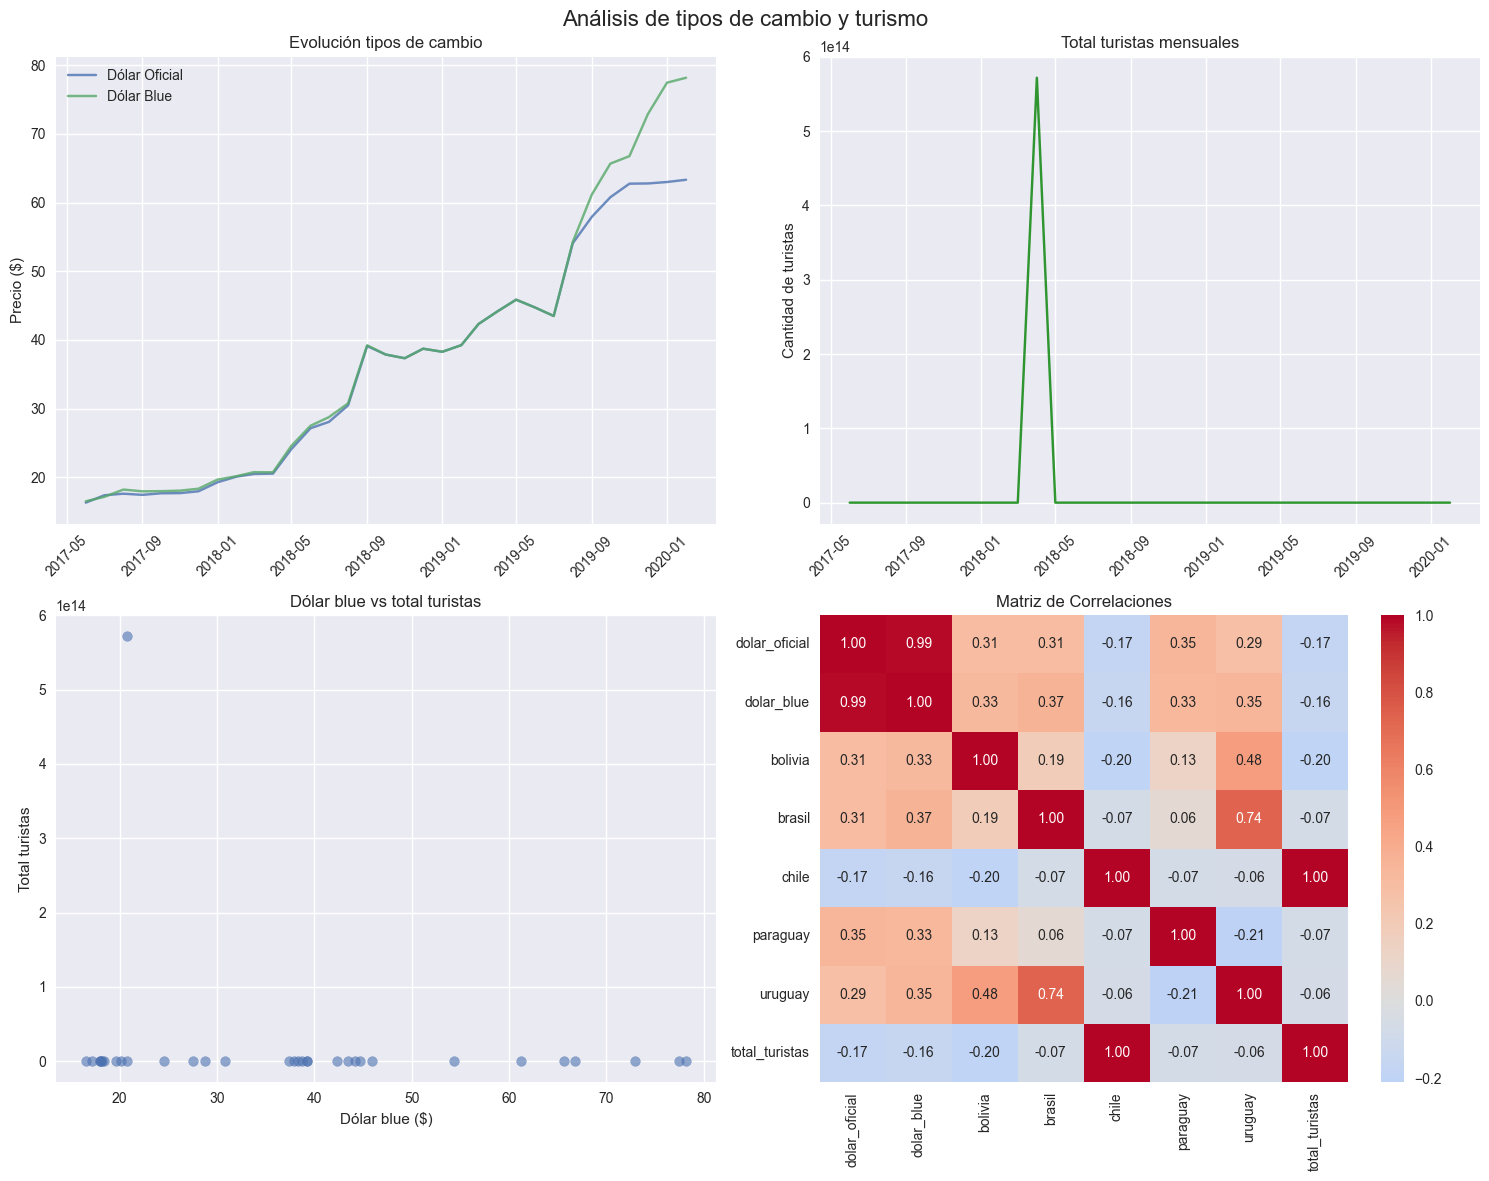

In [50]:
# Configuración para visualizaciones
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Análisis de tipos de cambio y turismo', fontsize=16)

# 1. Evolución de tipos de cambio
axes[0,0].plot(df_completo['fecha'], df_completo['dolar_oficial'], label='Dólar Oficial', alpha=0.8)
axes[0,0].plot(df_completo['fecha'], df_completo['dolar_blue'], label='Dólar Blue', alpha=0.8)
axes[0,0].set_title('Evolución tipos de cambio')
axes[0,0].set_ylabel('Precio ($)')
axes[0,0].legend()
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Total turistas por mes
df_completo['total_turistas'] = df_completo[['bolivia', 'brasil', 'chile', 'paraguay', 'uruguay']].sum(axis=1)
axes[0,1].plot(df_completo['fecha'], df_completo['total_turistas'], color='green', alpha=0.8)
axes[0,1].set_title('Total turistas mensuales')
axes[0,1].set_ylabel('Cantidad de turistas')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Scatter: Dólar Blue vs Total Turistas
axes[1,0].scatter(df_completo['dolar_blue'], df_completo['total_turistas'], alpha=0.6)
axes[1,0].set_title('Dólar blue vs total turistas')
axes[1,0].set_xlabel('Dólar blue ($)')
axes[1,0].set_ylabel('Total turistas')

# 4. Heatmap de correlaciones
correlaciones = df_completo.corr(numeric_only = True)    
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=axes[1,1])
axes[1,1].set_title('Matriz de Correlaciones')

plt.tight_layout()
plt.show()



In [52]:
# Identifico los outliers de cantidad de turistas
print("Outliers en total de turistas:")
Q1 = df_completo['total_turistas'].quantile(0.25) # devuelve el valor numérico tal que el 25% de los datos son menores a él
Q3 = df_completo['total_turistas'].quantile(0.75) # devuelve el valor numérico tal que el 75% de los datos son menores a él
IQR = Q3 - Q1 

outliers_turistas = df_completo[df_completo['total_turistas'] > (Q3 + 1.5 * IQR)] 

print(outliers_turistas[['fecha', 'total_turistas']])

Outliers en total de turistas:
        fecha  total_turistas
10 2018-04-01    5.718388e+14


In [53]:
# este valor es demasiado alto, por lo que voy a imputarlo con la mediana

# imputamos los outliers de tasa de empleo con la mediana

# mediana sin outliers
mediana_turistas = df_completo.loc[df_completo['total_turistas'] < (Q3 + 1.5 * IQR), 'total_turistas'].median() # valores mayores al límite superior del bigote 

# mediana con outliers
#mediana_turistas = df_completo['total_turistas'].median()

df_completo.loc[df_completo['fecha'] == '2018-04-01', 'total_turistas'] = mediana_turistas

In [54]:
outliers_turistas = df_completo[df_completo['total_turistas'] > (Q3 + 1.5 * IQR)] # valores mayores al límite superior del bigote
print(outliers_turistas[['fecha', 'total_turistas']])

Empty DataFrame
Columns: [fecha, total_turistas]
Index: []


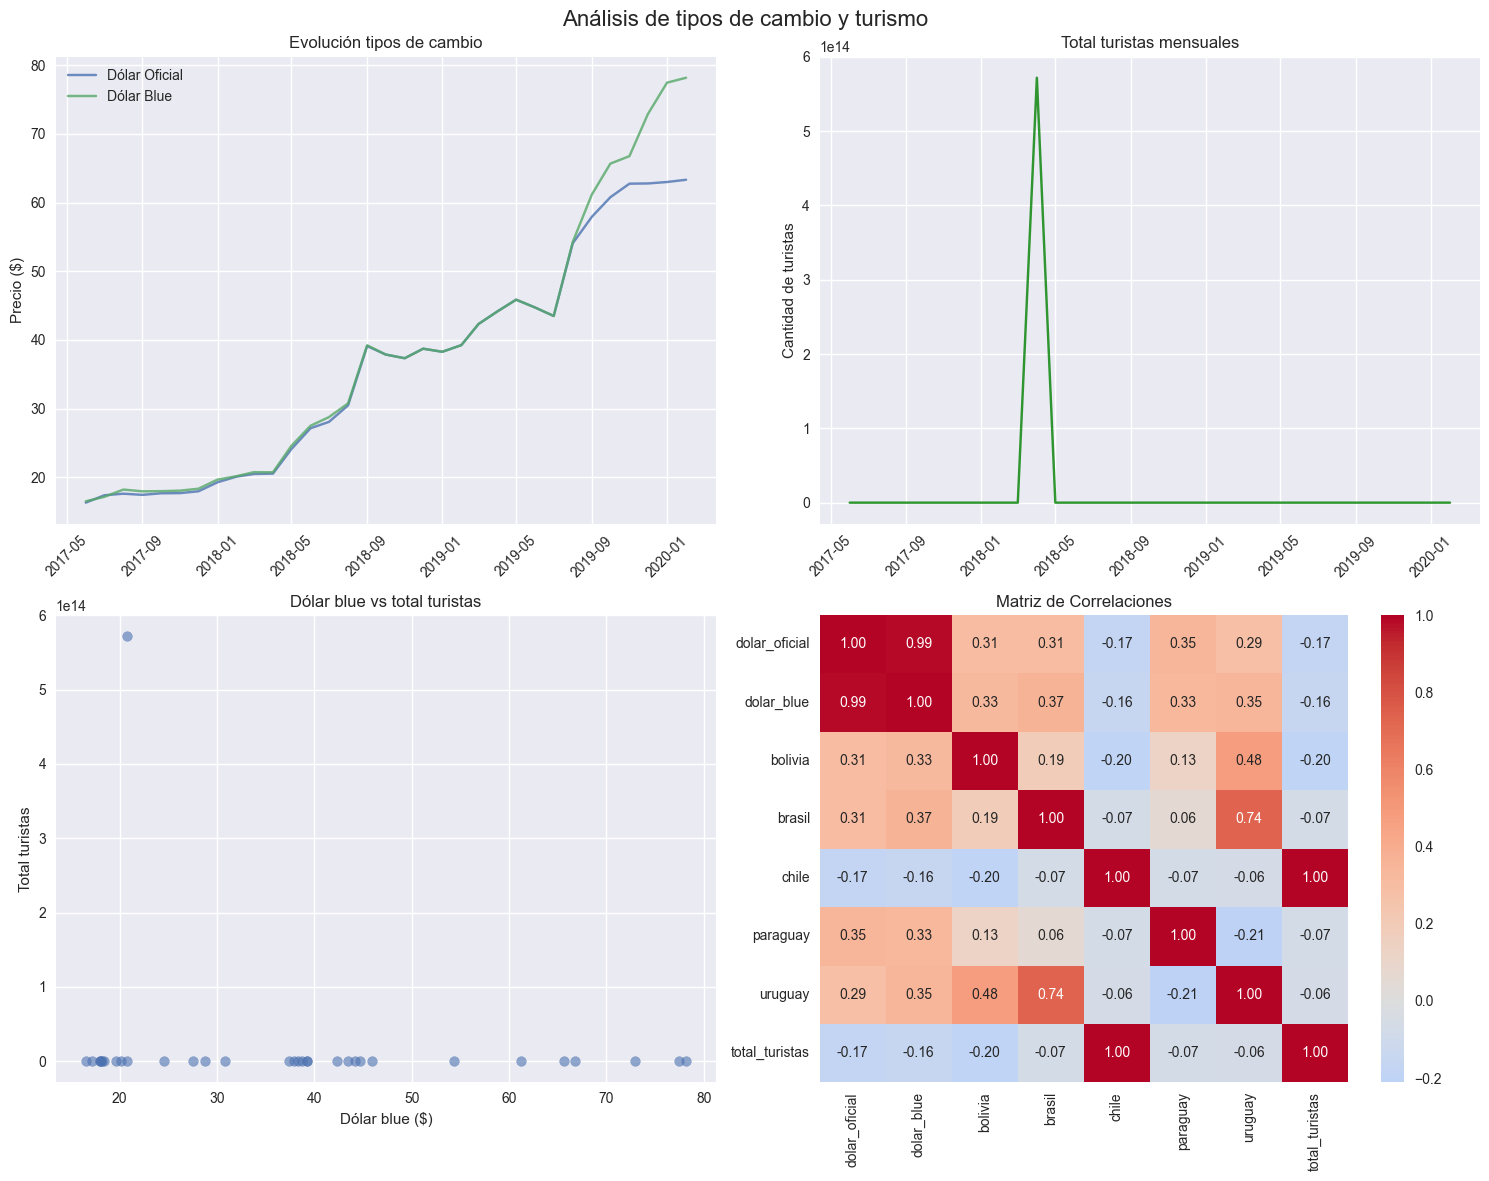

In [55]:
# Configuración para visualizaciones
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Análisis de tipos de cambio y turismo', fontsize=16)

# 1. Evolución de tipos de cambio
axes[0,0].plot(df_completo['fecha'], df_completo['dolar_oficial'], label='Dólar Oficial', alpha=0.8)
axes[0,0].plot(df_completo['fecha'], df_completo['dolar_blue'], label='Dólar Blue', alpha=0.8)
axes[0,0].set_title('Evolución tipos de cambio')
axes[0,0].set_ylabel('Precio ($)')
axes[0,0].legend()
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Total turistas por mes
df_completo['total_turistas'] = df_completo[['bolivia', 'brasil', 'chile', 'paraguay', 'uruguay']].sum(axis=1)
axes[0,1].plot(df_completo['fecha'], df_completo['total_turistas'], color='green', alpha=0.8)
axes[0,1].set_title('Total turistas mensuales')
axes[0,1].set_ylabel('Cantidad de turistas')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Scatter: Dólar Blue vs Total Turistas
axes[1,0].scatter(df_completo['dolar_blue'], df_completo['total_turistas'], alpha=0.6)
axes[1,0].set_title('Dólar blue vs total turistas')
axes[1,0].set_xlabel('Dólar blue ($)')
axes[1,0].set_ylabel('Total turistas')

# 4. Heatmap de correlaciones
correlaciones = df_completo.corr(numeric_only = True)    
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=axes[1,1])
axes[1,1].set_title('Matriz de Correlaciones')

plt.tight_layout()
plt.show()

